# 📚 [LAB 12] 2. 회귀분석의 가정 검정

In [4]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np

# 선형회귀를 위한 참조
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 결과 검정을 위한 참조
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, probplot, shapiro, kstest
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

In [5]:
origin = load_data("cars")
origin.head()

[data] https://data.hossam.kr/data/lab12_/cars.xlsx
[desc] 자동차의 속도(speed)에 따른 제동거리(dist) 조사 데이터 (출처: R 기본 데이터)

field    description
-------  -------------
speed    속도
dist     제동거리



,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


In [6]:
yname = "dist"
x = origin.drop(yname, axis=1)
y = origin[yname]
X = sm.add_constant(x)
fit = sm.OLS(y, X).fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           1.49e-12
Time:                        16:09:58   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5791      6.758     -2.601      0.0

In [7]:
y_pred = fit.predict(X)
y_pred.head()

0    -1.849460
1    -1.849460
2     9.947766
3     9.947766
4    13.880175
dtype: float64

In [8]:
y_pred = fit.fittedvalues
y_pred.head()

0    -1.849460
1    -1.849460
2     9.947766
3     9.947766
4    13.880175
dtype: float64

In [9]:
residual = origin["dist"] - y_pred
residual.head()

0     3.849460
1    11.849460
2    -5.947766
3    12.052234
4     2.119825
dtype: float64

In [10]:
residual = fit.resid
residual.head()

0     3.849460
1    11.849460
2    -5.947766
3    12.052234
4     2.119825
dtype: float64

In [11]:
df = origin.copy()
df["y_pred"] = y_pred
df["resid"] = residual
df.head()

,speed,dist,y_pred,resid
0,4,2,-1.849460,3.849460
1,4,10,-1.849460,11.849460
2,7,4,9.947766,-5.947766
3,7,22,9.947766,12.052234
4,8,16,13.880175,2.119825


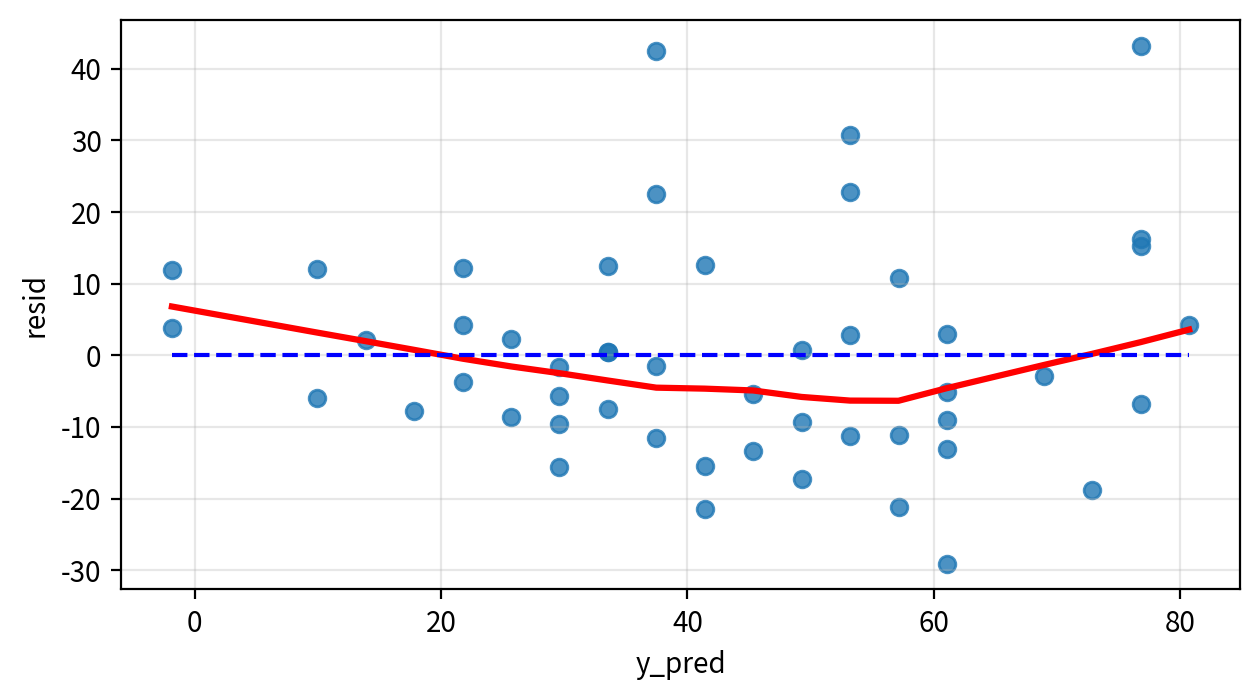

In [13]:
xmin = df["y_pred"].min()
xmax = df["y_pred"].max()
xrange = [xmin, xmax]
yrange = [0, 0]
# 1) 그래프 초기화
width_px = 1280  # 그래프 가로 크기
height_px = 720  # 그래프 세로 크기
rows = 1  # 그래프 행 수
cols = 1  # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) regplot 그리기
sb.regplot(data=df, x="y_pred", y="resid", lowess=True, line_kws={"color": "red"})
sb.lineplot(x=xrange, y=yrange, color="blue", linestyle="--")
# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3)  # 배경 격자 표시
# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

In [15]:
reset_res = linear_reset(fit, power=2, use_f=True)
print(f"RESET F-statistic: {reset_res.fvalue:.4f}")
print(f"p-value: {reset_res.pvalue:.4f}")
if reset_res.pvalue < 0.05:
    print("선형성/기능형 위배 가능성이 있음 (5% 유의수준)")
else:
    print("선형성 가정 위배 근거 없음 (5% 유의수준)")

RESET F-statistic: 2.2960
p-value: 0.1364
선형성 가정 위배 근거 없음 (5% 유의수준)


In [16]:
df["zscore"] = zscore(df["y_pred"])
df.head()

,speed,dist,y_pred,resid,zscore
0,4,2,-1.849460,3.849460,-2.177858
1,4,10,-1.849460,11.849460,-2.177858
2,7,4,9.947766,-5.947766,-1.604738
3,7,22,9.947766,12.052234,-1.604738
4,8,16,13.880175,2.119825,-1.413697


In [17]:
(x, y), _ = probplot(df["zscore"])
display(x[:5])
display(y[:5])

array([-2.20385432, -1.83293478, -1.61402323, -1.45296849, -1.32267759])

array([-2.17785805, -2.17785805, -1.60473751, -1.60473751, -1.41369733])

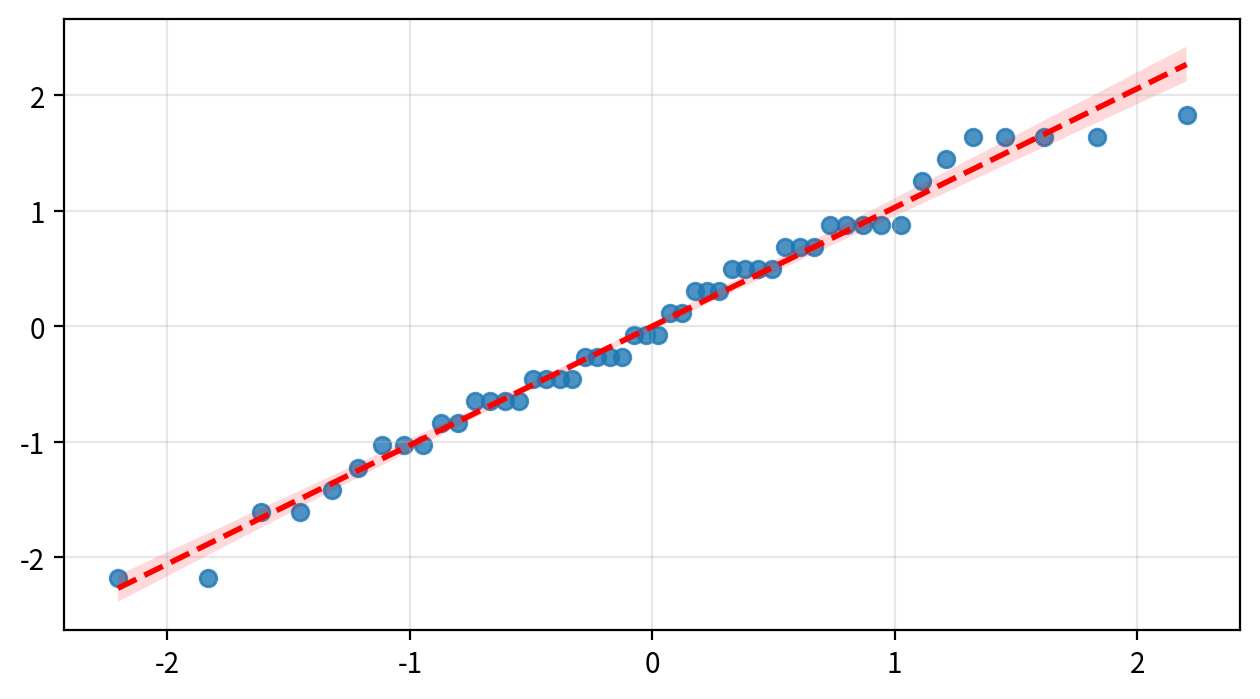

In [19]:
# 1) 그래프 초기화
width_px = 1280  # 그래프 가로 크기
height_px = 720  # 그래프 세로 크기
rows = 1  # 그래프 행 수
cols = 1  # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) regplot 그리기
sb.regplot(
    x=x, y=y, line_kws={"color": "red", "linestyle": "--", "linewidth": 2}  # 점선
)
# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3)  # 배경 격자 표시
# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

In [20]:
MSE_sq = np.sqrt(fit.mse_resid)  # 잔차 분산의 제곱근
r = fit.resid  # 잔차
r1 = r[(r > -MSE_sq) & (r < MSE_sq)].count() / r.count() * 100
r2 = r[(r > -2 * MSE_sq) & (r < 2 * MSE_sq)].count() / r.count() * 100
r3 = r[(r > -3 * MSE_sq) & (r < 3 * MSE_sq)].count() / r.count() * 100
mse_r = [r1, r2, r3]
print(f"루트 1MSE 구간에 포함된 잔차 비율: {r1:.2f}%")
print(f"루트 2MSE 구간에 포함된 잔차 비율: {r2:.2f}%")
print(f"루트 3MSE 구간에 포함된 잔차 비율: {r3:.2f}%")

루트 1MSE 구간에 포함된 잔차 비율: 74.00%
루트 2MSE 구간에 포함된 잔차 비율: 94.00%
루트 3MSE 구간에 포함된 잔차 비율: 100.00%


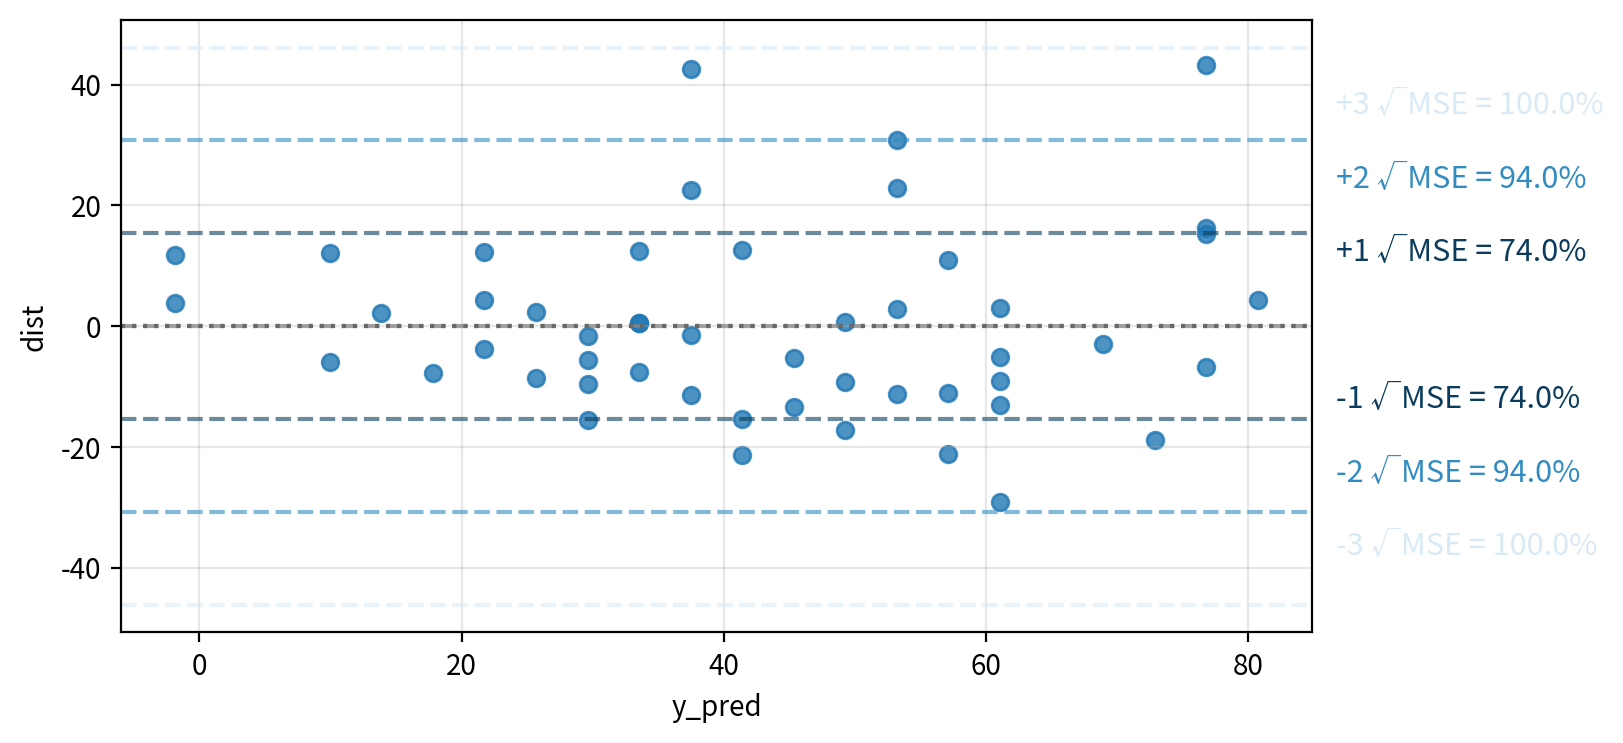

In [23]:
mse_sq = fit.mse_resid
mse_root = np.sqrt(mse_sq)
colors = ["#0B3C5D", "#328CC1", "#D9EAF7"]

# resid는 비율 계산할 때만 사용 (df랑 인덱스 맞음)
resid = fit.resid

# 1) 그래프 초기화
width_px = 1600
height_px = 720
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi, constrained_layout=True)

# 2) seaborn 기본 잔차도 (네가 쓰던 방식 유지)
sb.residplot(data=df, x="y_pred", y="dist", ax=ax)
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.7)

# 3) 꾸미기
ax.grid(True, alpha=0.3)

# 4) MSE 3단계 표시 (+k, -k 각각 텍스트)
for i, c in enumerate(colors):
    k = i + 1
    y_pos = k * mse_root  # ±k√MSE 위치

    # 수평선 두 개 ( +k, -k )
    ax.axhline(y=y_pos, color=c, linestyle="--", alpha=0.6)
    ax.axhline(y=-y_pos, color=c, linestyle="--", alpha=0.6)

    # ±k√MSE 안에 들어오는 잔차 비율(%)
    ratio = (np.abs(resid) <= y_pos).mean() * 100

    # + 쪽 텍스트 (위)
    ax.text(
        1.02,
        0.5 + 0.12 * k,
        f"+{k} √MSE = {ratio:.1f}%",
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=11,
        color=c,
    )

    # - 쪽 텍스트 (아래)
    ax.text(
        1.02,
        0.5 - 0.12 * k,
        f"-{k} √MSE = {ratio:.1f}%",
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=11,
        color=c,
    )

# 5) 출력
plt.show()
plt.close()

In [28]:
# 샘플 수에 따라 정규성 검정 선택
if len(origin) < 30:
    method = "Shapiro-Wilk"
    s, p = shapiro(df["resid"])
else:
    method = "Kolmogorov–Smirnov"
    mu = df["resid"].mean()
    sigma = df["resid"].std(ddof=1)
    s, p = kstest(df["resid"], "norm", args=(mu, sigma))
# 결과 문자열
result = f"{method} Test ::: statistic: {s:.3f}, p-value: {p:.3f}, {'대립' if p <=0.05 else '귀무'}가설 채택"
print(result)

Kolmogorov–Smirnov Test ::: statistic: 0.130, p-value: 0.341, 귀무가설 채택


In [ ]:
# Breusch–Pagan Test
names = ["LM Statistic", "LM p-value", "F Statistic", "F p-value"]
bp_test = het_breuschpagan(fit.resid, fit.model.exog)
bp = DataFrame(bp_test, index=names, columns=["value"])
display(bp)
# p-value는 F p-value를 기준으로 사용
p_bp = bp.loc["F p-value", "value"]
# 출력문 생성
bp_result = (
    f"Breusch–Pagan Test ::: "
    f"F = {bp.loc['F Statistic','value']:.3f}, "
    f"p-value = {p_bp:.3f}, "
    f"{'대립' if p_bp <= 0.05 else '귀무'}가설 채택 → "
    f"{'이분산성 존재(등분산 아님)' if p_bp <= 0.05 else '등분산성 만족'}"
)
print(bp_result)

,value
LM Statistic,3.214880
LM p-value,0.072972
F Statistic,3.298361
F p-value,0.075597


Breusch–Pagan Test //: F = 3.298, p-value = 0.076, 귀무가설 채택 → 등분산성 만족


In [31]:
dw = durbin_watson(df["resid"])
if 1.5 <= dw <= 2.5:
    interpretation = "잔차는 독립성을 만족함 (자기상관 없음)"
elif dw < 1.5:
    interpretation = "잔차에 양(+)의 자기상관이 존재할 가능성 있음 (독립성 위반)"
else:
    interpretation = "잔차에 음(–)의 자기상관이 존재할 가능성 있음 (독립성 위반)"
print(f"Durbin–Watson = {dw:.3f} ::: {interpretation}")

Durbin–Watson = 1.676 ::: 잔차는 독립성을 만족함 (자기상관 없음)
